<a href="https://www.kaggle.com/code/lalit7881/2026-middle-east-conflict-energy-crisis-dashboard?scriptVersionId=305276543" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/alitaqishah/iran-war-oil-shock-2026-brent-and-gas-tracker/iran_war_oil_prices_daily_2026.csv
/kaggle/input/datasets/alitaqishah/iran-war-oil-shock-2026-brent-and-gas-tracker/iran_war_gas_prices_by_state.csv
/kaggle/input/datasets/alitaqishah/iran-war-oil-shock-2026-brent-and-gas-tracker/iran_war_key_events_timeline.csv


## Loading dataset

In [2]:
daily  = pd.read_csv('/kaggle/input/datasets/alitaqishah/iran-war-oil-shock-2026-brent-and-gas-tracker/iran_war_oil_prices_daily_2026.csv')

states = pd.read_csv('/kaggle/input/datasets/alitaqishah/iran-war-oil-shock-2026-brent-and-gas-tracker/iran_war_gas_prices_by_state.csv')

events = pd.read_csv('/kaggle/input/datasets/alitaqishah/iran-war-oil-shock-2026-brent-and-gas-tracker/iran_war_key_events_timeline.csv')

In [3]:
# Check structure
print(daily.head())
print(states.head())
print(events.head())

# Info & missing values
print(daily.info())
print(states.info())
print(events.info())

print(daily.isnull().sum())
print(states.isnull().sum())
print(events.isnull().sum())

         date  brent_usd_barrel  wti_usd_barrel  dubai_usd_barrel  \
0  2026-02-09              67.4            62.1              66.8   
1  2026-02-10              69.3            64.2              68.4   
2  2026-02-14              71.2            65.8              70.1   
3  2026-02-18              72.8            67.4              71.8   
4  2026-02-24              71.5            66.2              70.4   

   us_gas_avg_gallon  us_diesel_avg_gallon  strait_hormuz_daily_ships  \
0               2.81                  3.68                        138   
1               2.83                  3.70                        138   
2               2.84                  3.71                        138   
3               2.85                  3.72                        138   
4               2.87                  3.74                        138   

   iran_production_mbpd                                          key_event  \
0                   3.3  Trump-Iran diplomatic talks described as 'v

In [4]:
prewar = daily.loc[daily['war_day'] == -1].iloc[0]
latest = daily.loc[daily['war_day'] == 21].iloc[0]

In [5]:
peak_brent = daily['brent_usd_barrel'].max()
hormuz_crisis = daily.loc[daily['war_day'] >= 1, 'strait_hormuz_daily_ships'].min()


In [6]:
print("=" * 55)
print(" IRAN WAR OIL SHOCK 2026 -- CRISIS SNAPSHOT")
print("=" * 55)

print(f"Brent Pre-War        : ${prewar['brent_usd_barrel']:.2f}/bbl")
print(f"Brent Today          : ${latest['brent_usd_barrel']:.2f}/bbl")
print(f"Brent Peak           : ${peak_brent:.2f}/bbl")
print(f"Brent Surge          : +{latest['brent_vs_prewar_pct']:.1f}%")

print(f"US Gas Pre-War       : ${prewar['us_gas_avg_gallon']:.2f}/gal")
print(f"US Gas Today         : ${latest['us_gas_avg_gallon']:.2f}/gal")
print(f"US Diesel Today      : ${latest['us_diesel_avg_gallon']:.2f}/gal")

print(f"Hormuz (Normal)      : 138 ships/day")
print(f"Hormuz (Crisis)      : {int(hormuz_crisis)} ships/day")

print(f"Iran Production (Pre): {prewar['iran_production_mbpd']} mbpd")
print(f"Iran Production (Now): {latest['iran_production_mbpd']} mbpd")

print(f"Highest State (CA)   : $5.53/gal")
print(f"Lowest State (MS)    : $3.12/gal")

print("=" * 55)

 IRAN WAR OIL SHOCK 2026 -- CRISIS SNAPSHOT
Brent Pre-War        : $73.10/bbl
Brent Today          : $110.30/bbl
Brent Peak           : $110.30/bbl
Brent Surge          : +50.9%
US Gas Pre-War       : $2.92/gal
US Gas Today         : $3.92/gal
US Diesel Today      : $5.10/gal
Hormuz (Normal)      : 138 ships/day
Hormuz (Crisis)      : 4 ships/day
Iran Production (Pre): 3.2 mbpd
Iran Production (Now): 1.6 mbpd
Highest State (CA)   : $5.53/gal
Lowest State (MS)    : $3.12/gal


## EDA

In [7]:
import matplotlib.ticker as mticker

## Oil Market Shock Timeline (Feb–Mar 2026)

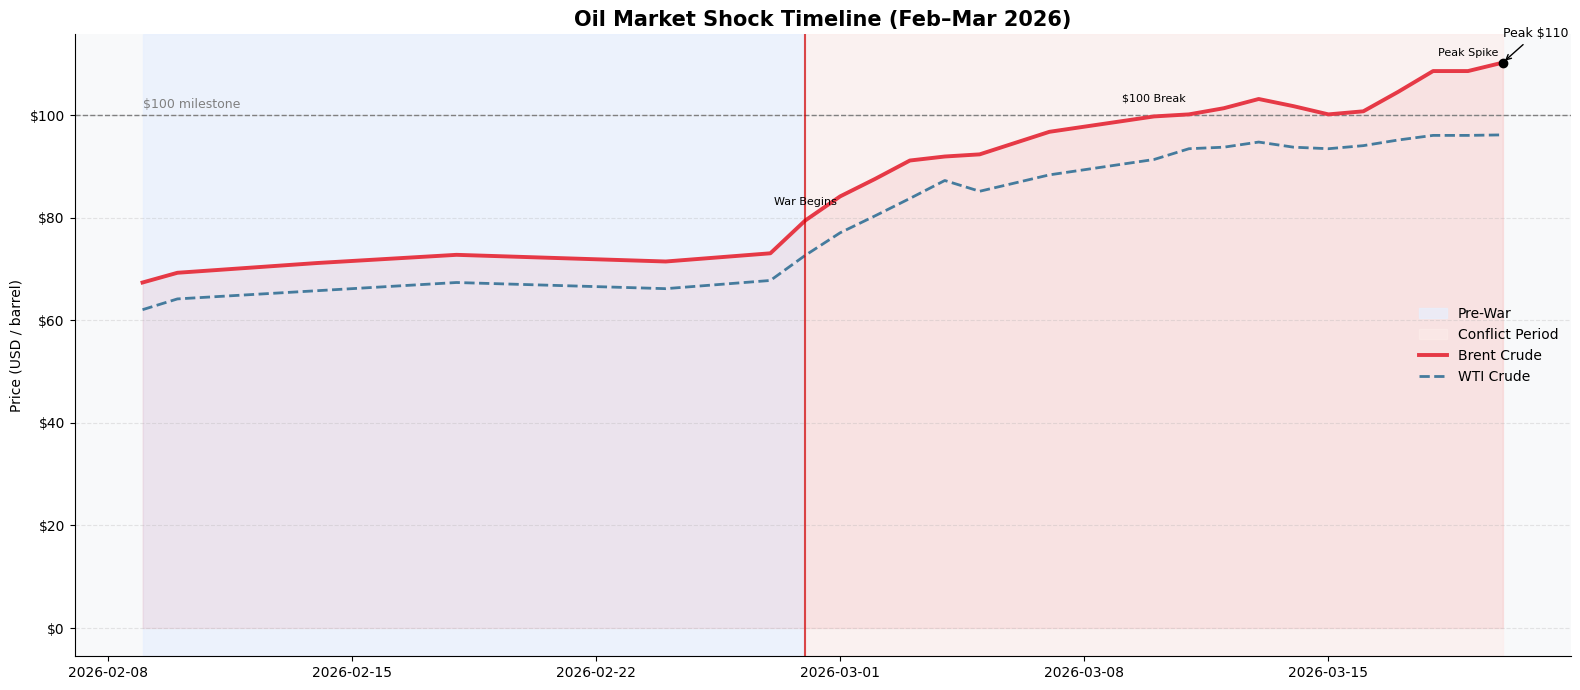

In [8]:
# --- FIX: Ensure datetime ---
daily['date'] = pd.to_datetime(daily['date'])

# --- Setup ---
fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('#f8f9fa')

# --- FIX: Proper Timestamp (no .values) ---
war_start = daily.loc[daily['war_day'] == 1, 'date'].iloc[0]

# --- Background zones ---
ax.axvspan(daily['date'].min(), war_start,
           color='#e8f0fe', alpha=0.7, label='Pre-War')

ax.axvspan(war_start, daily['date'].max(),
           color='#fdecea', alpha=0.6, label='Conflict Period')

# --- Reference line ---
ax.axhline(100, color='gray', lw=1, ls='--')
ax.text(daily['date'].min(), 101.5, '$100 milestone',
        color='gray', fontsize=9)

# --- Main lines ---
ax.plot(daily['date'], daily['brent_usd_barrel'],
        color='#e63946', lw=2.8, label='Brent Crude')

ax.plot(daily['date'], daily['wti_usd_barrel'],
        color='#457b9d', lw=2, ls='--', label='WTI Crude')

# --- Area fill ---
ax.fill_between(daily['date'], daily['brent_usd_barrel'],
                color='#e63946', alpha=0.08)

# --- Highlight peak ---
peak_idx = daily['brent_usd_barrel'].idxmax()
peak_date = daily.loc[peak_idx, 'date']
peak_price = daily.loc[peak_idx, 'brent_usd_barrel']

ax.scatter(peak_date, peak_price, color='black', zorder=5)
ax.annotate(f'Peak ${peak_price:.0f}',
            xy=(peak_date, peak_price),
            xytext=(peak_date, peak_price + 5),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=9)

# --- Simple annotations ---
events_simple = [
    ('2026-02-28', 'War Begins'),
    ('2026-03-10', '$100 Break'),
    ('2026-03-19', 'Peak Spike'),
]

for d, label in events_simple:
    d = pd.Timestamp(d)
    row = daily.loc[daily['date'] == d]
    if not row.empty:
        y = row['brent_usd_barrel'].values[0]
        ax.text(d, y + 3, label, fontsize=8, ha='center')

# --- War start line ---
ax.axvline(war_start, color='#d00000', lw=1.5, alpha=0.7)

# --- Styling ---
ax.set_title('Oil Market Shock Timeline (Feb–Mar 2026)',
             fontsize=15, weight='bold')

ax.set_ylabel('Price (USD / barrel)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))

ax.grid(True, axis='y', linestyle='--', alpha=0.3)
ax.legend(frameon=False)

# Clean look
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('oil_price_light_theme.png', dpi=150, bbox_inches='tight')
plt.show()

## Oil Shock: Shipping Collapse vs Price Surge (2026)

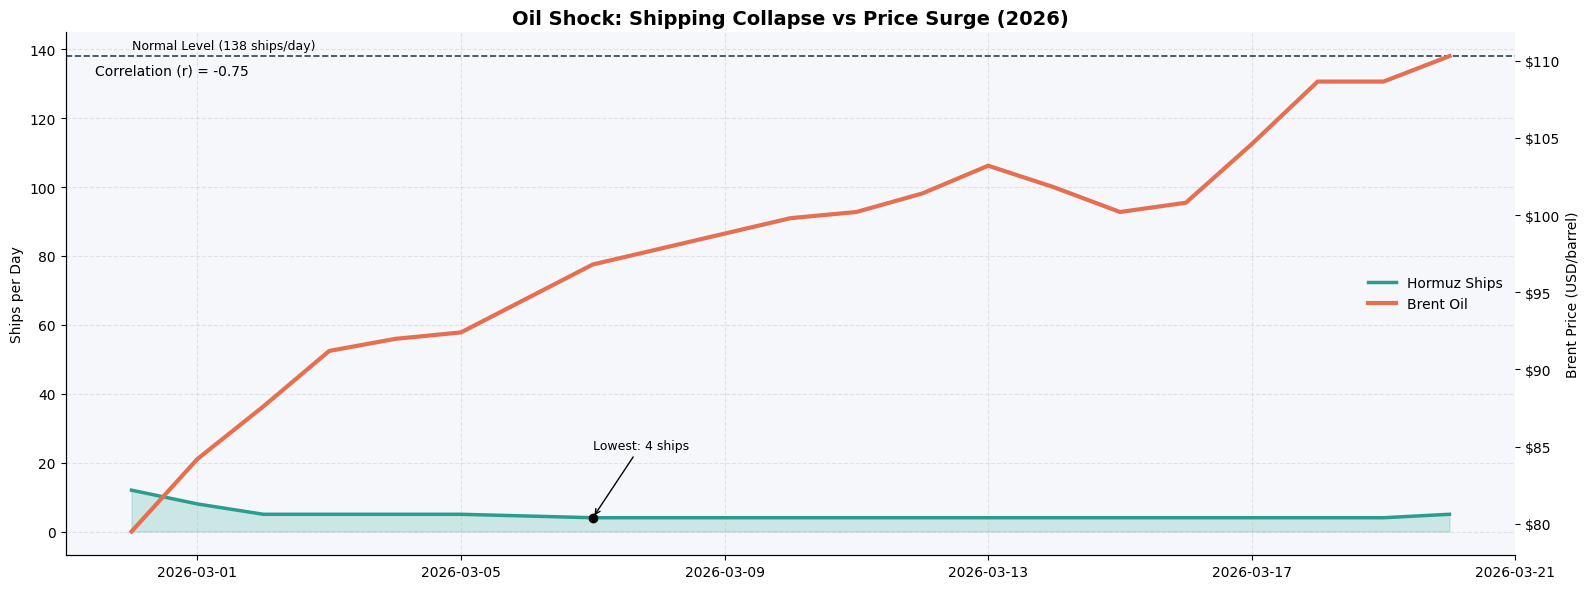

In [9]:
# Ensure datetime
daily['date'] = pd.to_datetime(daily['date'])

# Filter war period
war_df = daily[daily['war_day'] >= 1].copy()

# --- Setup ---
fig, ax1 = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('white')
ax1.set_facecolor('#f5f7fb')

# --- Hormuz ships (AREA CHART instead of bars) ---
ax1.plot(war_df['date'], war_df['strait_hormuz_daily_ships'],
         color='#2a9d8f', lw=2.5, label='Hormuz Ships')

ax1.fill_between(war_df['date'],
                 war_df['strait_hormuz_daily_ships'],
                 color='#2a9d8f', alpha=0.2)

# Reference line
ax1.axhline(138, color='#264653', lw=1.2, ls='--')
ax1.text(war_df['date'].iloc[0], 140,
         'Normal Level (138 ships/day)',
         fontsize=9)

ax1.set_ylabel('Ships per Day', fontsize=10)

# --- Brent (SECOND AXIS - smooth line) ---
ax2 = ax1.twinx()

ax2.plot(war_df['date'], war_df['brent_usd_barrel'],
         color='#e76f51', lw=3, label='Brent Oil')

ax2.set_ylabel('Brent Price (USD/barrel)', fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))

# --- Highlight lowest shipping point ---
min_idx = war_df['strait_hormuz_daily_ships'].idxmin()
min_date = war_df.loc[min_idx, 'date']
min_val = war_df.loc[min_idx, 'strait_hormuz_daily_ships']

ax1.scatter(min_date, min_val, color='black', zorder=5)
ax1.annotate(f'Lowest: {int(min_val)} ships',
             xy=(min_date, min_val),
             xytext=(min_date, min_val + 20),
             arrowprops=dict(arrowstyle='->'),
             fontsize=9)

# --- Correlation ---
corr = war_df['strait_hormuz_daily_ships'].corr(war_df['brent_usd_barrel'])
ax1.text(0.02, 0.92,
         f'Correlation (r) = {corr:.2f}',
         transform=ax1.transAxes,
         fontsize=10)

# --- Title ---
ax1.set_title('Oil Shock: Shipping Collapse vs Price Surge (2026)',
              fontsize=14, weight='bold')

# --- Grid & cleanup ---
ax1.grid(True, linestyle='--', alpha=0.3)

for spine in ['top', 'right']:
    ax1.spines[spine].set_visible(False)
    ax2.spines[spine].set_visible(False)

# --- Legend ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False)

plt.tight_layout()
plt.savefig('hormuz_trend_light.png', dpi=150, bbox_inches='tight')
plt.show()

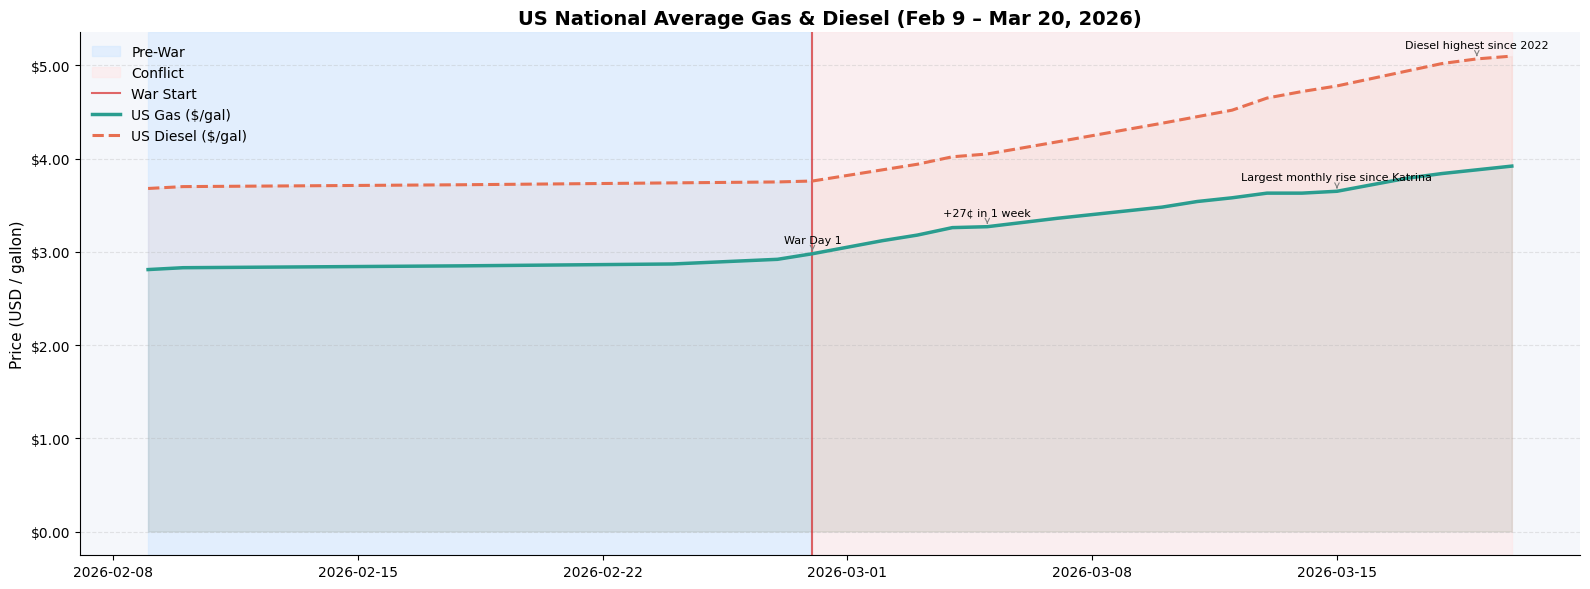

In [10]:
# Ensure date is datetime
daily['date'] = pd.to_datetime(daily['date'])

# --- Setup figure ---
fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('#f5f7fb')

# --- War start ---
war_start = daily.loc[daily['war_day'] == 1, 'date'].iloc[0]

# --- Highlight pre-war vs war period ---
ax.axvspan(daily['date'].min(), war_start, color='#d0e7ff', alpha=0.5, label='Pre-War')
ax.axvspan(war_start, daily['date'].max(), color='#ffe6e6', alpha=0.5, label='Conflict')

# Vertical line at war start
ax.axvline(war_start, color='#d62828', lw=1.5, alpha=0.7, label='War Start')

# --- Plot gas and diesel ---
ax.plot(daily['date'], daily['us_gas_avg_gallon'], color='#2a9d8f', lw=2.5, label='US Gas ($/gal)')
ax.plot(daily['date'], daily['us_diesel_avg_gallon'], color='#e76f51', lw=2.2, ls='--', label='US Diesel ($/gal)')

# --- Area fill for emphasis ---
ax.fill_between(daily['date'], daily['us_gas_avg_gallon'], alpha=0.1, color='#2a9d8f')
ax.fill_between(daily['date'], daily['us_diesel_avg_gallon'], alpha=0.07, color='#e76f51')

# --- Key annotations ---
annotations = [
    ('2026-02-28', 2.98, 'War Day 1'),
    ('2026-03-05', 3.27, '+27¢ in 1 week'),
    ('2026-03-15', 3.65, 'Largest monthly rise since Katrina'),
    ('2026-03-19', 5.07, 'Diesel highest since 2022'),
]

for date_str, price, label in annotations:
    d = pd.Timestamp(date_str)
    ax.annotate(label, xy=(d, price), xytext=(d, price + 0.12),
                fontsize=8, ha='center', color='black',
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

# --- Styling ---
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.2f'))
ax.set_title('US National Average Gas & Diesel (Feb 9 – Mar 20, 2026)',
             fontsize=14, weight='bold')
ax.set_ylabel('Price (USD / gallon)', fontsize=11)
ax.grid(True, axis='y', linestyle='--', alpha=0.3)

# --- Legend ---
ax.legend(loc='upper left', frameon=False, fontsize=10)

# Remove top/right spines
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('gas_diesel_light_theme.png', dpi=150, bbox_inches='tight')
plt.show()

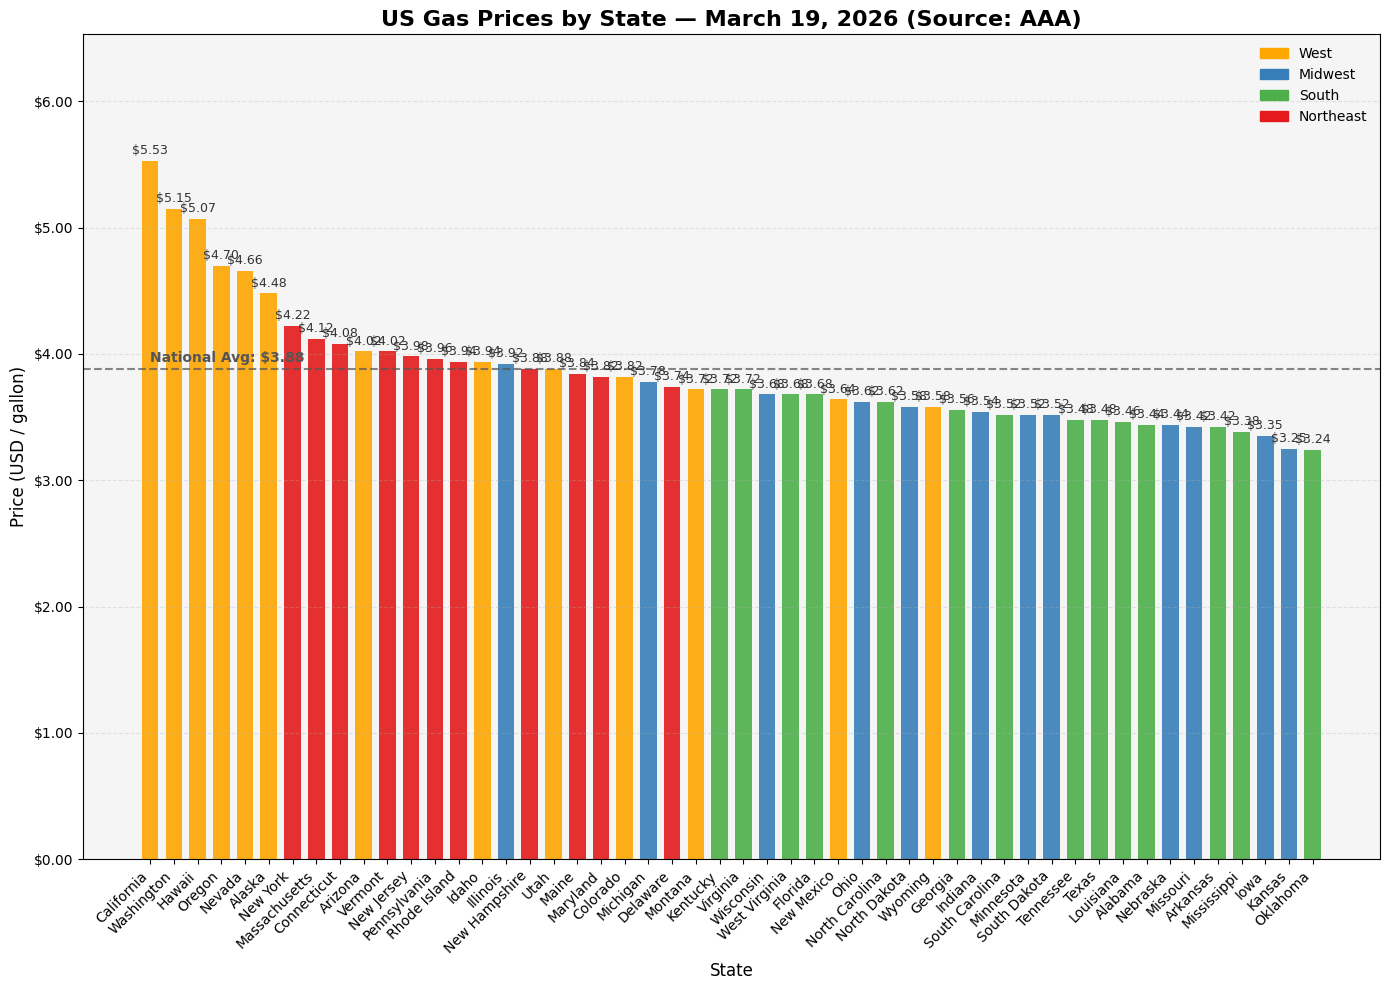

In [11]:
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
# --- Sort states by price ---
states_sorted = states.sort_values('gas_price_mar19_2026', ascending=False)

# --- New color palette per region ---
region_colors = {
    'West':      '#ffa600',    # orange
    'Midwest':   '#377eb8',    # blue
    'South':     '#4daf4a',    # green
    'Northeast': '#e41a1c',    # red
}
bar_colors = [region_colors.get(r, '#888888') for r in states_sorted['region']]

# --- Setup figure ---
fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor('white')
ax.set_facecolor('#f5f5f5')

# --- Vertical bars ---
bars = ax.bar(states_sorted['state'], states_sorted['gas_price_mar19_2026'],
              color=bar_colors, alpha=0.9, width=0.7)

# --- National average line ---
nat_avg = 3.88
ax.axhline(nat_avg, color='#555555', lw=1.5, ls='--', alpha=0.7)
ax.text(0, nat_avg + 0.03, f'National Avg: ${nat_avg:.2f}', color='#555555',
        fontsize=10, fontweight='bold', va='bottom')

# --- Price labels on top of bars ---
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.03,
            f'${height:.2f}', ha='center', va='bottom', fontsize=9, color='#333333')

# --- Legend for regions ---
legend_handles = [mpatches.Patch(color=c, label=r) for r, c in region_colors.items()]
ax.legend(handles=legend_handles, loc='upper right', frameon=False, fontsize=10)

# --- Styling ---
ax.set_title('US Gas Prices by State — March 19, 2026 (Source: AAA)',
             fontsize=16, weight='bold')
ax.set_ylabel('Price (USD / gallon)', fontsize=12)
ax.set_xlabel('State', fontsize=12)
ax.set_ylim(0, max(states_sorted['gas_price_mar19_2026']) + 1)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.2f'))
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.savefig('us_gas_prices_vertical.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# --- Ensure date column is datetime ---
display_events = events[['date', 'war_day', 'event_title', 'category',
                         'brent_price_that_day']].copy()

display_events['date'] = pd.to_datetime(display_events['date'])  # <-- Fix here

# Format date and prices
display_events['date'] = display_events['date'].dt.strftime('%b %d, %Y')
display_events['brent_price_that_day'] = display_events['brent_price_that_day'].apply(lambda x: f'${x:.2f}')

# Rename columns
display_events.columns = ['Date', 'War Day', 'Event', 'Category', 'Brent Price']

# --- Category colors ---
cat_colors = {
    'Conflict Start':          'background-color: #ffcccb; color: #800000',
    'Energy Infrastructure':   'background-color: #d0f0c0; color: #006400',
    'Policy Response':         'background-color: #cce5ff; color: #003366',
    'Military Escalation':     'background-color: #f0c0f0; color: #660066',
    'Price Record':            'background-color: #fff2cc; color: #996600',
}

def color_category(val):
    return cat_colors.get(val, '')

# --- Styled table ---
styled = (display_events.style
          .applymap(color_category, subset=['Category'])
          .set_properties(**{
              'background-color': '#fefefe',
              'color': '#222222',
              'border': '1px solid #dddddd',
              'font-size': '12px',
              'text-align': 'center'
          })
          .set_table_styles([{
              'selector': 'th',
              'props': [('background-color', '#e0e0e0'),
                        ('color', '#444444'),
                        ('font-size', '13px'),
                        ('border', '1px solid #cccccc'),
                        ('text-align', 'center')]
          }])
          .hide(axis='index')
)

display(styled)

Date,War Day,Event,Category,Brent Price
"Feb 28, 2026",1,War Begins,Conflict Start,$79.50
"Mar 02, 2026",3,Qatar LNG Shutdown,Energy Infrastructure,$87.60
"Mar 04, 2026",5,IEA Emergency Release,Policy Response,$91.98
"Mar 07, 2026",8,Dubai Crude Record,Price Record,$96.80
"Mar 10, 2026",11,Brent Crosses $100,Price Milestone,$99.80
"Mar 13, 2026",14,Sanctioned Oil Released,Policy Response,$103.20
"Mar 15, 2026",16,Kharg Island Strike,Military Escalation,$100.20
"Mar 18, 2026",19,South Pars Attack,Energy Infrastructure,$108.65
"Mar 18, 2026",19,Qatar 17% LNG Offline,Energy Infrastructure,$108.65
"Mar 19, 2026",20,Brent Hits $119,Price Record,$108.65
